## Datatype
## date ranges and outliers
## Duplicated


In [ ]:
file = 'datasets/banking_dirty.csv'

In [3]:
import pandas as pd
import numpy as np

In [ ]:
df = pd.read_csv(file)

In [ ]:
df.columns

In [ ]:
df.head(5)

In [ ]:
df.info()

## Date Types Check

In [ ]:
def check_missing_values(df):
    missing_stats = pd.DataFrame({
        'total_missing': df.isnull().sum(),
        'percent_missing': (df.isnull().sum() / len(df) * 100).round(2)
    }).sort_values('percent_missing', ascending=False)
    
    missing_stats['impact'] = missing_stats['percent_missing'].apply(
        lambda x: 'High' if x > 15 else ('Medium' if x > 5 else 'Low')
    )
    return missing_stats

In [ ]:
check_missing_values(df)

In [ ]:
df.rename(columns={'Age': 'age'}, inplace=True)

In [ ]:
# Replace 33 with NaN and convert to Int64
df['age'] = df['age'].replace(33, np.nan)

In [ ]:
# Fill missing values with the 33
df['age'] = df['age'].fillna(33).astype("Int64")


In [ ]:
df['cust_id'].describe()
#categorical data

In [ ]:
df['age'].describe()
#numerical data

In [ ]:
assert df['age'].dtype == 'Float64' ,"wrong data type"


In [ ]:
type(df['age'])

In [ ]:
df['age'] = df['age'].astype('Int64')

In [ ]:
df['age'].describe()

### Data Ranges

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
plt.hist(df['age'], bins=10, edgecolor='black')
plt.title('Distribution of Age')

In [ ]:
age_counts = df.groupby('age').size().reset_index(name='count').sort_values('age',ascending=False)
age_counts

In [ ]:
# Identify outliers using IQR greater than 60 and less than 30
df.loc[df['age'] <=30, 'age'] = 30
df.loc[df['age'] >=60, 'age'] = 60

In [ ]:
age_counts = df.groupby('age').size().reset_index(name='count').sort_values('age',ascending=False)
age_counts

In [ ]:
import datetime as dt

In [ ]:
df['birth_date'] = pd.to_datetime(df['birth_date']).dt.date
df['birth_date'].head(5)

In [ ]:
df

In [ ]:
today = pd.to_datetime(dt.date.today())
computed_age = ((today - pd.to_datetime(df['birth_date'])).dt.days / 365.25).astype(int)
df =  df[(computed_age <= 60) & (computed_age >= 30)].copy()


In [ ]:
df.head()

In [ ]:
df['age'].unique()

In [ ]:
plt.hist(df['age'], bins=20, edgecolor='black')
plt.title('Distribution of Age')

In [ ]:
duplicates = df.duplicated()
duplicates

#### Duplicates 

In [ ]:
#who opened account on the same day
duplicates = df.duplicated(subset=['account_opened'], keep=False)


In [ ]:
df[duplicates].sort_values('account_opened')

## TXT

In [1]:
file = 'datasets/restaurants_L2_dirty.csv'

In [4]:
dataset = pd.read_csv(file)

In [5]:
dataset.drop(columns=['Unnamed: 0'], inplace=True)

In [6]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 82 entries, 0 to 81
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   name    82 non-null     str  
 1   addr    82 non-null     str  
 2   city    82 non-null     str  
 3   phone   82 non-null     int64
 4   type    82 non-null     str  
dtypes: int64(1), str(4)
memory usage: 7.0 KB


In [7]:
types = dataset['type'].unique()
types

<ArrowStringArray>
[        'american',      'californian',         'japanese',
     'cajun/creole',         'hot dogs',           'diners',
            'delis',       'hamburgers',          'seafood',
          'italian',     'coffee shops',          'russian',
      'steakhouses',  'mexican/tex-mex',     'noodle shops',
          'mexican',   'middle eastern',            'asian',
       'vietnamese',      'health food', 'american ( new )',
 'pacific new wave',       'indonesian',         'eclectic',
          'chicken',        'fast food',    'southern/soul',
        'coffeebar',      'continental',   'french ( new )',
         'desserts',          'chinese',            'pizza']
Length: 33, dtype: str

In [8]:
types = pd.Series(types).str.replace(r'/.*|[\(\)]', '', regex=True)
types.str.strip()

0             american
1          californian
2             japanese
3                cajun
4             hot dogs
5               diners
6                delis
7           hamburgers
8              seafood
9              italian
10        coffee shops
11             russian
12         steakhouses
13             mexican
14        noodle shops
15             mexican
16      middle eastern
17               asian
18          vietnamese
19         health food
20       american  new
21    pacific new wave
22          indonesian
23            eclectic
24             chicken
25           fast food
26            southern
27           coffeebar
28         continental
29         french  new
30            desserts
31             chinese
32               pizza
dtype: str

In [14]:
inconsistent_categories = set(dataset['type']).difference(types)

In [15]:
inconsistent_categories

{'american ( new )',
 'cajun/creole',
 'french ( new )',
 'mexican/tex-mex',
 'southern/soul'}

In [16]:
inconsistent_categories_rows = dataset['type'].isin(inconsistent_categories)

In [17]:
dataset = dataset[~inconsistent_categories_rows]

In [18]:
dataset

,name,addr,city,phone,type
0,kokomo,6333 w. third st.,la,2139330773,american
1,feenix,8358 sunset blvd. west,hollywood,2138486677,american
2,parkway,510 s. arroyo pkwy .,pasadena,8187951001,californian
3,r-23,923 e. third st.,los angeles,2136877178,japanese
5,pink's,709 n. la brea ave.,la,2139314223,hot dogs
...,...,...,...,...,...
77,feast,1949 westwood blvd.,west la,3104750400,chinese
78,mulberry,17040 ventura blvd.,encino,8189068881,pizza
79,matsuhissa,129 n. la cienega blvd.,beverly hills,3106599639,asian
80,jiraffe,502 santa monica blvd,santa monica,3109176671,californian


In [20]:
dataset['type'].value_counts()

type
american            20
italian              7
californian          5
coffee shops         5
asian                4
hot dogs             3
diners               3
delis                3
hamburgers           3
mexican              3
seafood              2
noodle shops         2
pacific new wave     2
japanese             1
russian              1
steakhouses          1
middle eastern       1
vietnamese           1
health food          1
indonesian           1
eclectic             1
chicken              1
fast food            1
coffeebar            1
continental          1
desserts             1
chinese              1
pizza                1
Name: count, dtype: int64

In [22]:
dataset['type'] = dataset['type'].str.title() #upper , # lower

In [24]:
dataset['type'].value_counts()

type
American            20
Italian              7
Californian          5
Coffee Shops         5
Asian                4
Hot Dogs             3
Diners               3
Delis                3
Hamburgers           3
Mexican              3
Seafood              2
Noodle Shops         2
Pacific New Wave     2
Japanese             1
Russian              1
Steakhouses          1
Middle Eastern       1
Vietnamese           1
Health Food          1
Indonesian           1
Eclectic             1
Chicken              1
Fast Food            1
Coffeebar            1
Continental          1
Desserts             1
Chinese              1
Pizza                1
Name: count, dtype: int64

In [34]:
dataset['city'] = dataset['city'].str.strip() #space trim

In [32]:
dataset['city'].value_counts()

city
la                   12
los angeles          11
new york              9
santa monica          6
beverly hills         5
pasadena              4
west la               4
hollywood             2
studio city           2
venice                2
w. hollywood          2
encino                2
westlake village      2
westwood              2
mar vista             1
chinatown             1
monterey park         1
rancho park           1
redondo beach         1
marina del rey        1
culver city           1
burbank               1
malibu                1
seal beach            1
northridge            1
st. hermosa beach     1
Name: count, dtype: int64

In [45]:
category_map = {
    "Los Angeles (Core)": ["la", "los angeles", "hollywood", "chinatown", "west la", "westwood", "rancho park", "mar vista"],
    "Beach Cities": ["santa monica", "venice", "marina del rey", "redondo beach", "malibu", "seal beach", "st. hermosa beach"],
    "San Fernando Valley": ["studio city", "encino", "northridge"],
    "Other LA County": ["beverly hills", "pasadena", "w. hollywood", "westlake village", "monterey park", "culver city", "burbank"],
    "Outside SoCal": ["new york"]
}

In [46]:

dataset['District'] = dataset['city'].map(category_map)

In [47]:
dataset['District'].value_counts()

Series([], Name: count, dtype: int64)

In [53]:
dataset['phone'].value_counts()

phone
2139330773    1
2138486677    1
8187951001    1
2136877178    1
2139314223    1
             ..
3104750400    1
8189068881    1
3106599639    1
3109176671    1
3103767786    1
Name: count, Length: 77, dtype: int64

In [59]:
digits = dataset['phone'].astype(str).str.len()

In [61]:
dataset .loc[digits != 10, 'phone'] = np.nan

In [62]:
dataset

,name,addr,city,phone,type,District
0,kokomo,6333 w. third st.,la,2.139331e+09,American,NaN
1,feenix,8358 sunset blvd. west,hollywood,2.138487e+09,American,NaN
2,parkway,510 s. arroyo pkwy .,pasadena,8.187951e+09,Californian,NaN
3,r-23,923 e. third st.,los angeles,2.136877e+09,Japanese,NaN
5,pink's,709 n. la brea ave.,la,2.139314e+09,Hot Dogs,NaN
...,...,...,...,...,...,...
77,feast,1949 westwood blvd.,west la,3.104750e+09,Chinese,NaN
78,mulberry,17040 ventura blvd.,encino,8.189069e+09,Pizza,NaN
79,matsuhissa,129 n. la cienega blvd.,beverly hills,3.106600e+09,Asian,NaN
80,jiraffe,502 santa monica blvd,santa monica,3.109177e+09,Californian,NaN


In [71]:
assert  dataset['phone'].astype(str).str.contains(r"[+-]").any() == False, "Phone numbers should not contain '+' or '-' characters"

In [72]:
missing = dataset[dataset['phone'].isnull()]

In [73]:
missing

,name,addr,city,phone,type,District


In [74]:
dataset.isna().sum()

name         0
addr         0
city         0
phone        0
type         0
District    77
dtype: int64

In [75]:
pip install pandas missingno

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [80]:
import missingno as msno
import pandas as pd
import matplotlib.pyplot as plt

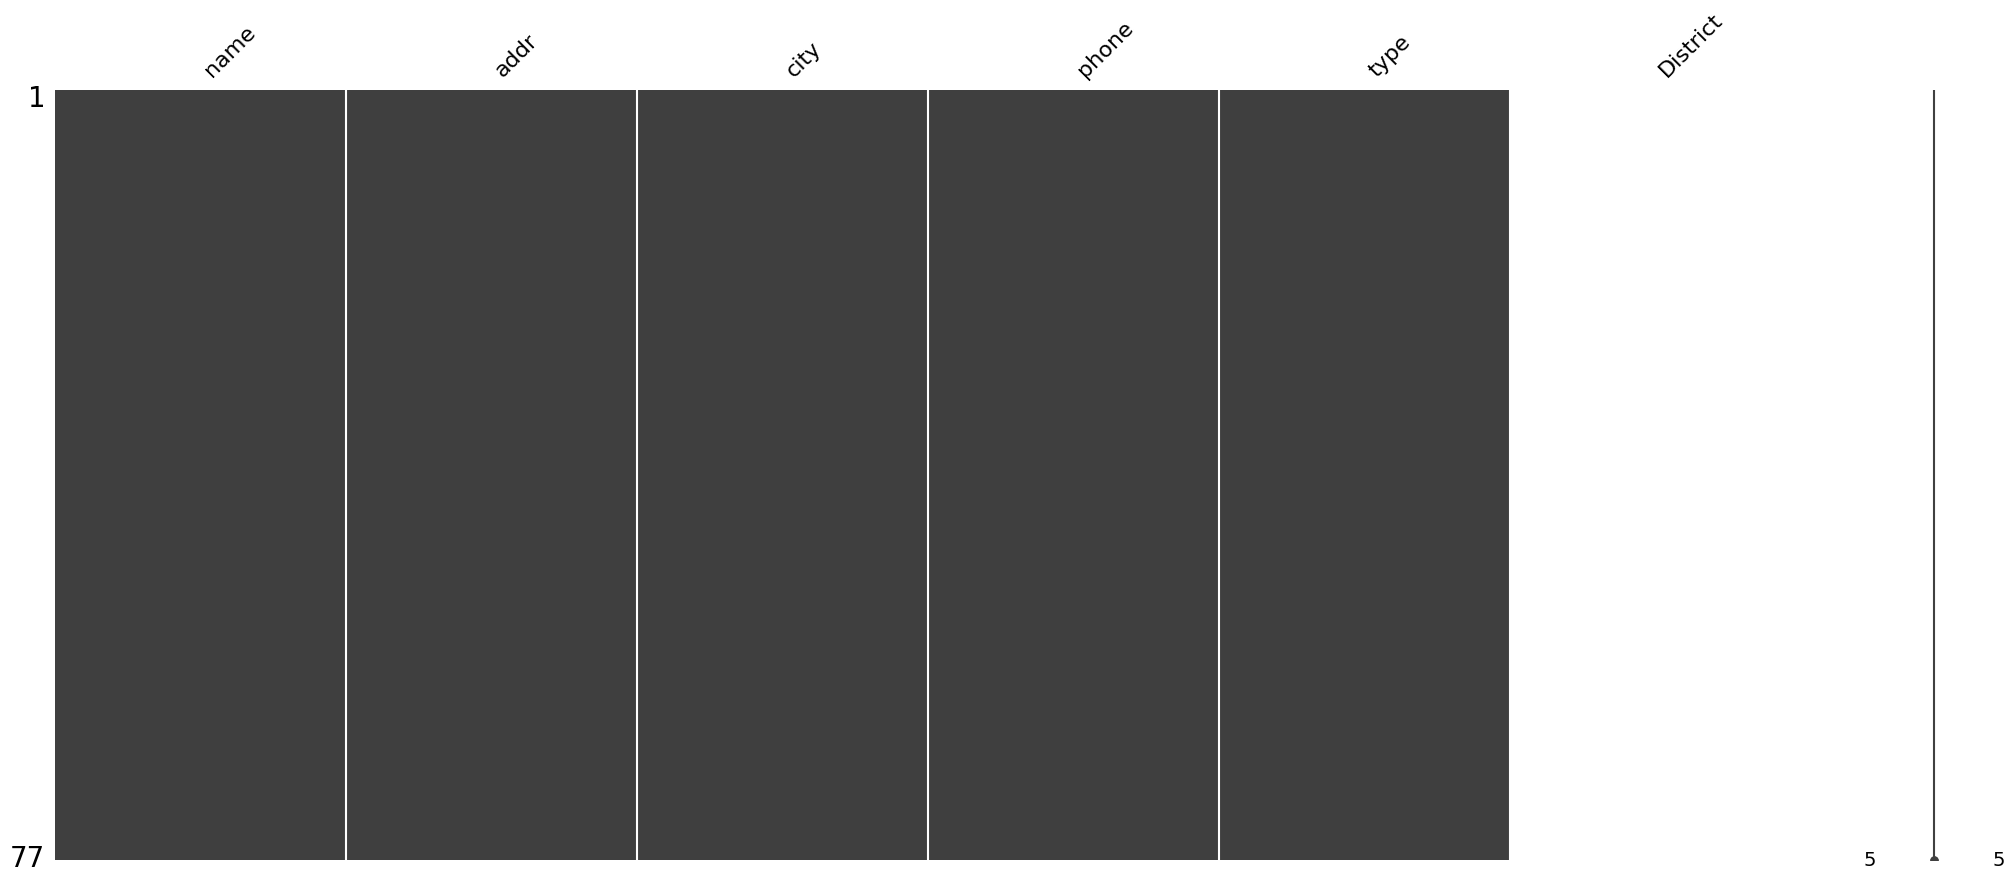

In [81]:
msno.matrix(dataset)
plt.show()